## Gaussian Blue Noise Sampling

In this notebook, we generate samples of Gaussian Blue Noise and use that to count linear regions in neural networks. We can then compare the variance properties to the simple iid random sampling (binomial point process).

#### Imports

In [345]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import importlib

In [519]:
import gbn_bounded_4
import spectrum_nd

In [907]:
# Run this line whenever you make a change to the file
importlib.reload(gbn_bounded_4)

<module 'gbn_bounded_4' from '/Users/gautamchauhan/Desktop/MSc Project Code/GBN_code_python/gbn_bounded_4.py'>

#### Blue Noise in 2D:

Generate blue noise:

In [908]:
result = gbn_bounded_4.sample_bounded_gbn(
    point_count=1000,
    dims=2,
    bounds=[[-1,1] for i in range(2)],
    sigma=1,
    iterations=10000,
    seed=5,
)

points = result.points

2D scatterplot of blue noise points:

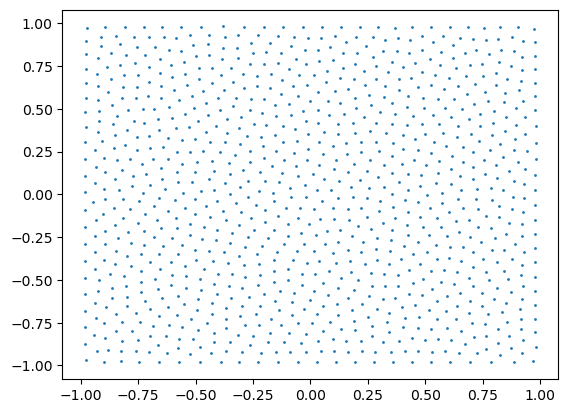

In [909]:
plt.scatter(points[:,0],points[:,1],s=1)

3D scatterplot of blue noise points (only for dimension 3):

In [910]:
spectrum, frequencies = spectrum_nd.power_spectrum(points,size=32,device="auto",return_frequencies=True)

Plot the amplitude against the magnitude of frequency along one radius:

In [911]:
diagonal_magnitudes = [np.sqrt(2*i**2) for i in range(32)]
diagonal_magnitudes = diagonal_magnitudes/max(diagonal_magnitudes)
diagonals = [spectrum[i,i] for i in range(32,64)]

Text(0, 0.5, 'Amplitude')

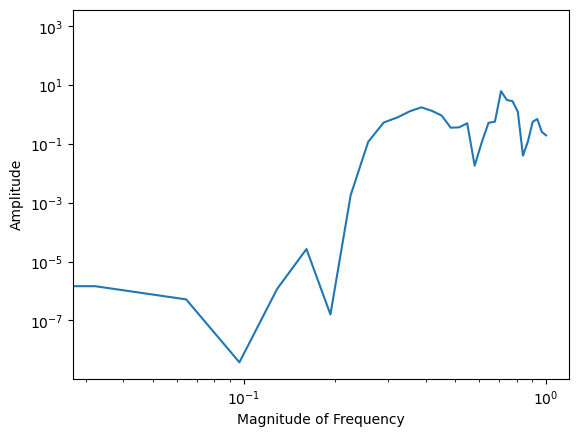

In [912]:
plt.loglog(diagonal_magnitudes,diagonals)
plt.xlabel("Magnitude of Frequency")
plt.ylabel("Amplitude")

#### Blue Noise in 3D:

In [926]:
result = gbn_bounded_4.sample_bounded_gbn(
    point_count=1000,
    dims=3,
    bounds=[[-1,1] for i in range(3)],
    sigma=1,
    iterations=100000,
    project=False,
    seed=1,
)

points = result.points

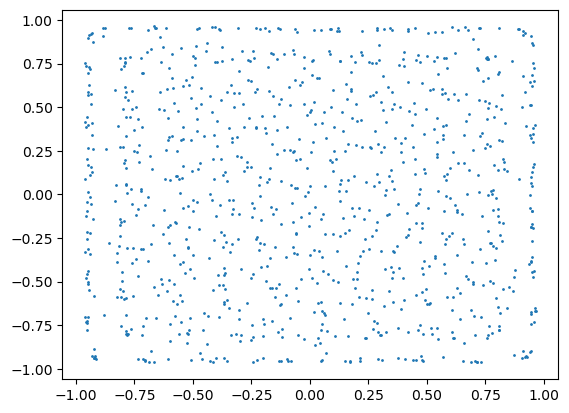

In [927]:
plt.scatter(points[:,0],points[:,1],s=1)

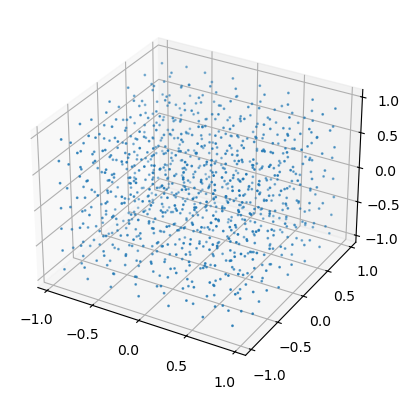

In [928]:
fig = plt.figure()
axs = fig.add_subplot(projection="3d")
axs.scatter(points[:,0],points[:,1],points[:,2],s=1)

In [929]:
spectrum, frequencies = spectrum_nd.power_spectrum(points,size=32,device="auto",return_frequencies=True)

In [930]:
diagonal_magnitudes = [np.sqrt(3*i**2) for i in range(32)]
diagonal_magnitudes = diagonal_magnitudes/max(diagonal_magnitudes)
diagonals = [spectrum[i,i,i] for i in range(32,64)]

Text(0, 0.5, 'Amplitude')

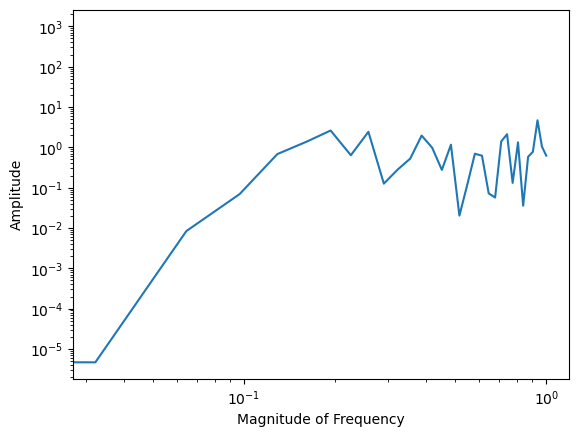

In [931]:
plt.loglog(diagonal_magnitudes,diagonals)
plt.xlabel("Magnitude of Frequency")
plt.ylabel("Amplitude")

Tasks:
1. Work out why code appears to work in 2D but not higher dimensions
2. Work out how to make it faster
   - Use original C++ code instead of python implementation?
   - Modify python code to consider local repulsive term rather than global?